In [34]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [35]:
# Menggabungkan semua data dari semua file CSV
dataset = pd.read_csv('D:/KULIAH/TA-DESAK/model/sampling_nonsummary.csv')

In [36]:
# Melihat unique value pada kolom "label"
dataset["Label"].unique()

array(['relevan', 'berlebihan', 'nonrelevan'], dtype=object)

In [37]:
# Hapus baris yang memiliki NaN di kolom "label"
dataset = dataset.dropna(subset=["Label"])

# Melihat unique value pada kolom "label"
dataset["Label"].unique()

array(['relevan', 'berlebihan', 'nonrelevan'], dtype=object)

In [38]:
dataset[dataset['Title_Content'].isna()]

,Title_Content,Label


In [39]:
dataset = dataset.dropna(subset=['Title_Content'])

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Content  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


In [40]:
dataset.head(20)

,Title_Content,Label
0,Prabowo Sarankan Otorita Prioritaskan Bangun G...,relevan
1,Warga Sebut Mobil Nyangkut di Separator Margon...,relevan
2,Penyidikan Kasus Surya Darmadi Dihentikan KPK ...,relevan
3,Horor Korban Jambret Terseret Motor Dikira Rib...,relevan
4,KPK Periksa Eks Anggota DPR Miryam S Haryani T...,relevan
5,"Merasa Dirugikan, Anak Musisi Laporkan Penyeba...",relevan
6,Viral Tunanetra Sulit Jalan gegara Trotoar Jak...,relevan
7,"Dijamin JKN, Pensiunan ASN di Toraja Utara Jal...",berlebihan
8,Kemeriahan PKKMB UNJA: Rektor Naik Traktor hin...,relevan
9,Jaksa Agung Perintahkan Jampidsus Selesaikan T...,relevan


# Delete Karakter

In [41]:
dataset.head(10)

,Title_Content,Label
0,Prabowo Sarankan Otorita Prioritaskan Bangun G...,relevan
1,Warga Sebut Mobil Nyangkut di Separator Margon...,relevan
2,Penyidikan Kasus Surya Darmadi Dihentikan KPK ...,relevan
3,Horor Korban Jambret Terseret Motor Dikira Rib...,relevan
4,KPK Periksa Eks Anggota DPR Miryam S Haryani T...,relevan
5,"Merasa Dirugikan, Anak Musisi Laporkan Penyeba...",relevan
6,Viral Tunanetra Sulit Jalan gegara Trotoar Jak...,relevan
7,"Dijamin JKN, Pensiunan ASN di Toraja Utara Jal...",berlebihan
8,Kemeriahan PKKMB UNJA: Rektor Naik Traktor hin...,relevan
9,Jaksa Agung Perintahkan Jampidsus Selesaikan T...,relevan


In [42]:
dataset['Title_Content'] = dataset['Title_Content'].str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)

In [43]:
dataset.head(10)

,Title_Content,Label
0,Prabowo Sarankan Otorita Prioritaskan Bangun G...,relevan
1,Warga Sebut Mobil Nyangkut di Separator Margon...,relevan
2,Penyidikan Kasus Surya Darmadi Dihentikan KPK ...,relevan
3,Horor Korban Jambret Terseret Motor Dikira Rib...,relevan
4,KPK Periksa Eks Anggota DPR Miryam S Haryani T...,relevan
5,Merasa Dirugikan Anak Musisi Laporkan Penyeba...,relevan
6,Viral Tunanetra Sulit Jalan gegara Trotoar Jak...,relevan
7,Dijamin JKN Pensiunan ASN di Toraja Utara Jal...,berlebihan
8,Kemeriahan PKKMB UNJA Rektor Naik Traktor hin...,relevan
9,Jaksa Agung Perintahkan Jampidsus Selesaikan T...,relevan


In [44]:
dataset['Title_Content'] = dataset['Title_Content'].str.lower()
dataset.head()

,Title_Content,Label
0,prabowo sarankan otorita prioritaskan bangun g...,relevan
1,warga sebut mobil nyangkut di separator margon...,relevan
2,penyidikan kasus surya darmadi dihentikan kpk ...,relevan
3,horor korban jambret terseret motor dikira rib...,relevan
4,kpk periksa eks anggota dpr miryam s haryani t...,relevan


In [45]:
dataset.head(10)

,Title_Content,Label
0,prabowo sarankan otorita prioritaskan bangun g...,relevan
1,warga sebut mobil nyangkut di separator margon...,relevan
2,penyidikan kasus surya darmadi dihentikan kpk ...,relevan
3,horor korban jambret terseret motor dikira rib...,relevan
4,kpk periksa eks anggota dpr miryam s haryani t...,relevan
5,merasa dirugikan anak musisi laporkan penyeba...,relevan
6,viral tunanetra sulit jalan gegara trotoar jak...,relevan
7,dijamin jkn pensiunan asn di toraja utara jal...,berlebihan
8,kemeriahan pkkmb unja rektor naik traktor hin...,relevan
9,jaksa agung perintahkan jampidsus selesaikan t...,relevan


# Classification

In [46]:
import os
import re
import string
import numpy as np
import pandas as pd
import nltk
import tensorflow as tf

from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, Adamax, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, SpatialDropout1D
from tensorflow.keras import regularizers

In [47]:
dataset['Label'].value_counts()

Label
relevan       4926
berlebihan    4890
nonrelevan    4500
Name: count, dtype: int64

In [48]:
dataset.groupby(dataset['Label']).count()

,Title_Content
Label,
berlebihan,4890
nonrelevan,4500
relevan,4926


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

import warnings as wrn
wrn.filterwarnings('ignore', category = DeprecationWarning)
wrn.filterwarnings('ignore', category = FutureWarning)
wrn.filterwarnings('ignore', category = UserWarning)
wrn.filterwarnings('ignore', category = RuntimeWarning)

<Axes: title={'center': 'Category Count'}, xlabel='count', ylabel='Label'>

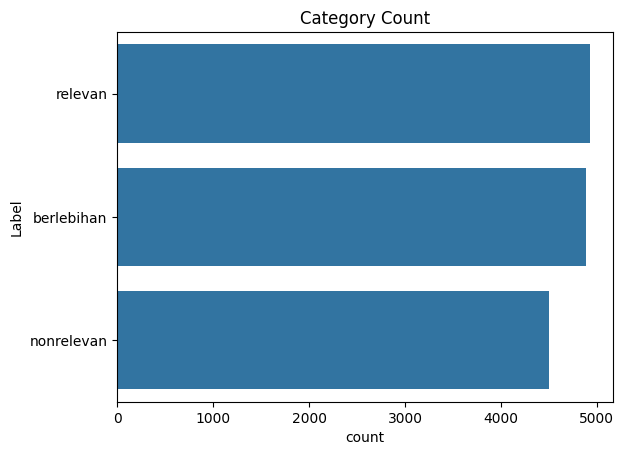

In [50]:
plt.title('Category Count')
sns.countplot(dataset['Label'])

In [51]:
kategori = pd.get_dummies(dataset.Label)
dataset = pd.concat([dataset, kategori], axis=1)
dataset = dataset.drop(columns='Label')
dataset.sample(5)

,Title_Content,berlebihan,nonrelevan,relevan
12782,id go manajemen 2018 pengumuman dikabarkan mes...,True,False,False
10788,barbie kumalasari sebut ibunya pernah jadi age...,False,True,False
9340,bantah jokowi soal ikn keputusan rakyat rocky...,True,False,False
4701,prediksi susunan pemain manchester united vs a...,True,False,False
3385,della rizki beber rahasia rebut gelar pertama ...,True,False,False


In [52]:
feature = dataset['Title_Content']
label = dataset[['berlebihan', 'nonrelevan', 'relevan']].values

In [53]:
from sklearn.model_selection import train_test_split
feature_latih, feature_test, label_latih, label_test = train_test_split(feature, label, test_size=0.2, random_state=42)

In [54]:
pad_type = 'pre'
trunc_type = 'pre'

# Tokenize our training data
tokenizer = Tokenizer(num_words=58700, oov_token='x')

tokenizer.fit_on_texts(feature_latih)

# # Hitung jumlah kata unik + 1 (karena index dimulai dari 1, dan 0 untuk padding)
# vocab_size = len(tokenizer.word_index) + 1
# print("Ukuran kosakata:", vocab_size)

# Encode training data sentences into sequences
sekuens_latih = tokenizer.texts_to_sequences(feature_latih)
sekuens_test = tokenizer.texts_to_sequences(feature_test)

# Get max training sequence length
maxlen = max([len(x) for x in sekuens_latih])

# Pad the training sequences
padded_latih = pad_sequences(sekuens_latih, padding=pad_type, truncating=trunc_type, maxlen=maxlen)
padded_test = pad_sequences(sekuens_test, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

kode asli

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=58700, output_dim=64, input_length=maxlen),
    tf.keras.layers.SpatialDropout1D(0.3),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.build(input_shape=(None, maxlen))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 2128, 64)          3756800   
                                                                 
 spatial_dropout1d (SpatialD  (None, 2128, 64)         0         
 ropout1D)                                                       
                                                                 
 bidirectional (Bidirectiona  (None, 2128, 128)        66048     
 l)                                                              
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                        

In [56]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.9 and logs.get('val_accuracy')>0.9):
      print("\nAkurasi telah mencapai >90%!")
      self.model.stop_training = True
callbacks = myCallback()

In [57]:
num_epochs = 10
hist = model.fit(padded_latih, label_latih, epochs=num_epochs,
                    validation_data=(padded_test, label_test),
                    verbose=2, callbacks=[callbacks])

Epoch 1/10
358/358 - 104s - loss: 1.0983 - accuracy: 0.3390 - val_loss: 1.0980 - val_accuracy: 0.3520 - 104s/epoch - 289ms/step
Epoch 2/10
358/358 - 96s - loss: 1.0982 - accuracy: 0.3414 - val_loss: 1.0980 - val_accuracy: 0.3520 - 96s/epoch - 269ms/step
Epoch 3/10
358/358 - 99s - loss: 1.0987 - accuracy: 0.3347 - val_loss: 1.0980 - val_accuracy: 0.3520 - 99s/epoch - 276ms/step
Epoch 4/10
358/358 - 100s - loss: 1.0984 - accuracy: 0.3345 - val_loss: 1.0980 - val_accuracy: 0.3520 - 100s/epoch - 280ms/step
Epoch 5/10
358/358 - 96s - loss: 1.0985 - accuracy: 0.3379 - val_loss: 1.0980 - val_accuracy: 0.3523 - 96s/epoch - 267ms/step
Epoch 6/10
358/358 - 101s - loss: 1.0985 - accuracy: 0.3357 - val_loss: 1.0980 - val_accuracy: 0.3520 - 101s/epoch - 281ms/step
Epoch 7/10
358/358 - 96s - loss: 1.0987 - accuracy: 0.3380 - val_loss: 1.0980 - val_accuracy: 0.3520 - 96s/epoch - 268ms/step
Epoch 8/10
358/358 - 95s - loss: 1.0986 - accuracy: 0.3370 - val_loss: 1.0980 - val_accuracy: 0.3523 - 95s/epoch

90/90 [==============================] - 11s 116ms/step


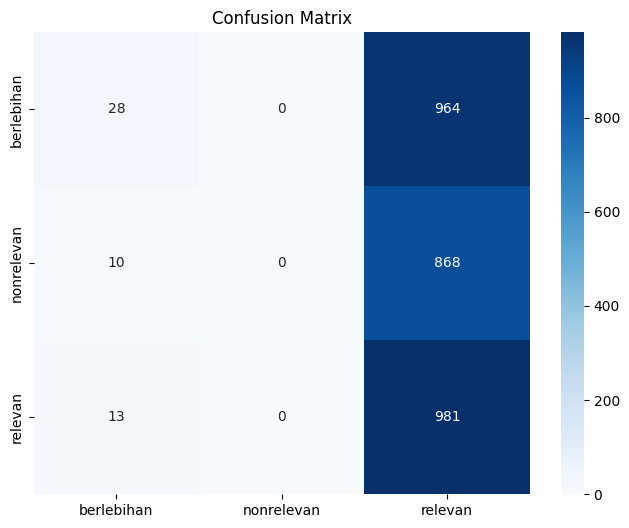

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Prediksi label dari data uji
label_prediksi = model.predict(padded_test)
label_prediksi = [list(prediksi).index(max(prediksi)) for prediksi in label_prediksi]

# Konversi one-hot encoded labels menjadi label kelas tunggal
label_asli = [list(label).index(1) for label in label_test]

# Buat confusion matrix
cm = confusion_matrix(label_asli, label_prediksi)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['berlebihan', 'nonrelevan', 'relevan'], yticklabels=['berlebihan', 'nonrelevan', 'relevan'])
plt.title('Confusion Matrix')
plt.show()

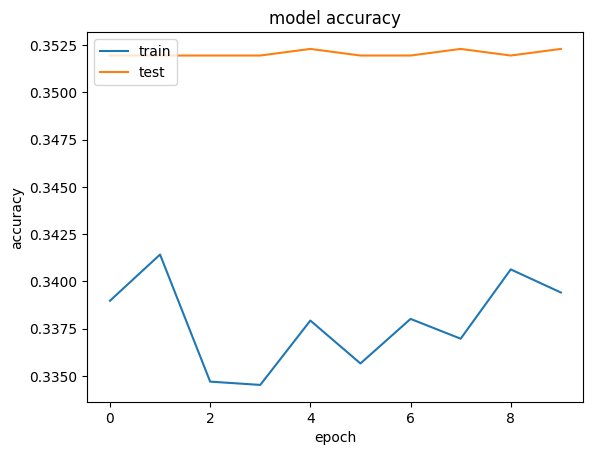

In [59]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

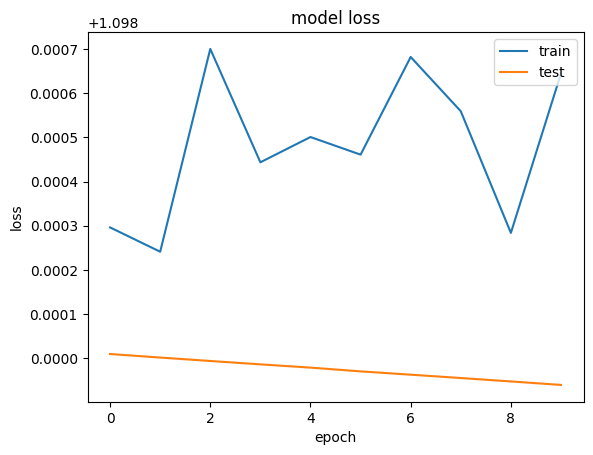

In [60]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Prediksi label dari data uji
label_prediksi = model.predict(padded_test)
label_prediksi = [list(prediksi).index(max(prediksi)) for prediksi in label_prediksi]

# Konversi one-hot encoded labels menjadi label kelas tunggal
label_asli = [list(label).index(1) for label in label_test]

# Hitung akurasi
accuracy = sum([1 for true, pred in zip(label_asli, label_prediksi) if true == pred]) / len(label_asli)
print(f"Akurasi pada data uji: {accuracy * 100:.2f}%")

# Hitung Precision, Recall, dan F1-Score
precision = precision_score(label_asli, label_prediksi, average='weighted')
recall = recall_score(label_asli, label_prediksi, average='weighted')
f1 = f1_score(label_asli, label_prediksi, average='weighted')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")


90/90 [==============================] - 11s 117ms/step
Akurasi pada data uji: 35.23%
Precision: 0.311
Recall: 0.352
F1-Score: 0.197


In [62]:
from sklearn.metrics import classification_report

# Menghitung Precision, Recall, dan F1-Score
report = classification_report(label_asli, label_prediksi, target_names=['berlebihan', 'nonrelevan', 'relevan'])
print(report)

              precision    recall  f1-score   support

  berlebihan       0.55      0.03      0.05       992
  nonrelevan       0.00      0.00      0.00       878
     relevan       0.35      0.99      0.52       994

    accuracy                           0.35      2864
   macro avg       0.30      0.34      0.19      2864
weighted avg       0.31      0.35      0.20      2864



In [63]:
import pickle
# Save the model to a file
model.save('modellstm_nonsummary_bilstm.h5')

# Save the tokenizer to a file using pickle
with open('tokenizer_nonsum_bilstm.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Evaluasi 

## ROC-Curve

In [64]:
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [65]:
# 1. Load tokenizer
with open('tokenizer_nonsum_bilstm.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

# 2. Tokenisasi dan padding untuk feature_test
sekuens_test = tokenizer.texts_to_sequences(feature_test)

# Gunakan pad_type, trunc_type, dan maxlen yang sama seperti training
pad_type = 'pre'
trunc_type = 'pre'
maxlen = max([len(x) for x in tokenizer.texts_to_sequences(feature_latih)])  # <- Sama seperti saat training

padded_test = pad_sequences(sekuens_test, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

# 3. Load model
model = load_model('modellstm_nonsummary_bilstm.h5')

# 4. Prediksi probabilitas
y_score = model.predict(padded_test)

90/90 [==============================] - 12s 121ms/step


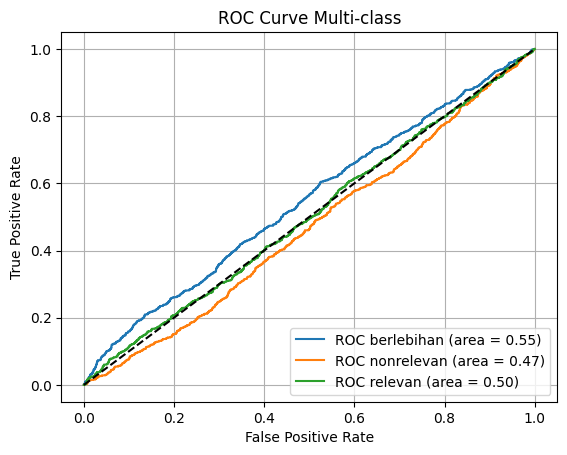

In [66]:

target_names = ['berlebihan', 'nonrelevan', 'relevan']
n_target = len(target_names)

# Binarisasi label_test (kalau label_test kamu berupa angka: 0, 1, 2)
y_true = label_binarize(label_test, classes=range(n_target))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_target):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC {target_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multi-class')
plt.legend(loc='lower right')
plt.grid()
plt.show()